In [3]:
# Load a COLMAP reconstruction using pycolmap
import pycolmap
import pathlib

# Define the path to the reconstruction model directory
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762035762715/0')

# Load the reconstruction
reconstruction = pycolmap.Reconstruction(model_path)

# Print basic info about the reconstruction
print(f"Number of registered images: {len(reconstruction.images)}")
print(f"Number of 3D points: {len(reconstruction.points3D)}")

Number of registered images: 59
Number of 3D points: 6030


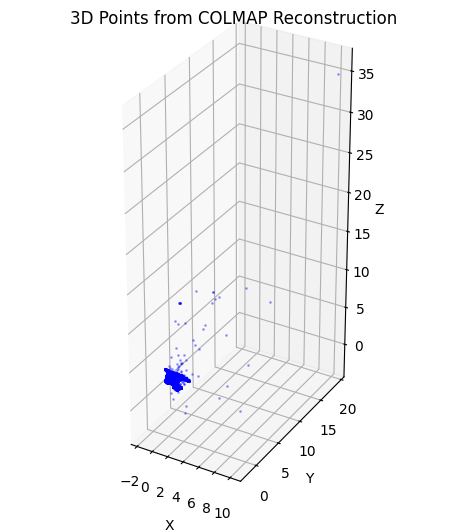

In [4]:
# Plot the 3D points from the reconstruction
import utils

utils.colmap_3d_points(reconstruction)

In [5]:
utils.colmap_3d_points_interactive(reconstruction)


In [16]:
reconstruction.images[65]

Image(image_id=65, camera=Camera(camera_id=64), name="r_66.png", has_pose=1, triangulated=464/3817)

In [17]:
help(reconstruction.images[65])

Help on Image in module pycolmap._core object:

class Image(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      Image
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __copy__(...)
 |      __copy__(self: pycolmap._core.Image) -> pycolmap._core.Image
 |
 |  __deepcopy__(...)
 |      __deepcopy__(self: pycolmap._core.Image, arg0: dict) -> pycolmap._core.Image
 |
 |  __getstate__(...)
 |      __getstate__(self: pycolmap._core.Image, /) -> dict
 |
 |  __init__(...)
 |      __init__(*args, **kwargs)
 |      Overloaded function.
 |
 |      1. __init__(self: pycolmap._core.Image) -> None
 |
 |      2. __init__(self: pycolmap._core.Image, name: str = '', points2D: pycolmap._core.Point2DList = Point2DList(), camera_id: typing.SupportsInt = pycolmap.INVALID_CAMERA_ID, image_id: typing.SupportsInt = pycolmap.INVALID_IMAGE_ID) -> None
 |
 |      3. __init__(self: pycolmap._core.Image, name: str = '', keypoints: typing.Annotat

In [23]:
reconstruction.images[65].cam_from_world()

Rigid3d(rotation_xyzw=[0.0893206, -0.216797, -0.173179, 0.956572], translation=[0.618743, -0.987678, 1.7999])

In [25]:
reconstruction.image(65).cam_from_world()

Rigid3d(rotation_xyzw=[0.0893206, -0.216797, -0.173179, 0.956572], translation=[0.618743, -0.987678, 1.7999])

In [28]:
type(reconstruction.images)

pycolmap._core.ImageMap

In [42]:
camera_translations = [item.cam_from_world().translation for item in reconstruction.images.values()]

In [57]:
camera_translations

[array([-0.80128725, -2.86450325,  4.78137545]),
 array([ 0.61874304, -0.98767752,  1.79990314]),
 array([ 0.16041351, -1.90238932,  2.25874706]),
 array([-0.29490594, -1.62966442,  2.06826651]),
 array([ 0.25432934, -1.64881258,  2.07037963]),
 array([ 0.08841429, -2.01592547,  2.36296717]),
 array([0.00665435, 0.07958829, 1.52834151]),
 array([ 0.44580083, -1.57061988,  2.01268718]),
 array([ 0.19721186, -0.88680266,  1.69423249]),
 array([-0.09041592, -0.43266246,  1.5872616 ]),
 array([0.11594006, 0.14862655, 1.55497783]),
 array([0.45886779, 0.39190862, 1.61413888]),
 array([-0.64200396, -0.78672999,  1.8067671 ]),
 array([-0.99681249, -1.03594227,  1.92383173]),
 array([ 0.89568082, -2.48425545,  3.17168014]),
 array([-0.99982321,  0.08739087,  1.72330375]),
 array([ 0.95797891, -1.07567791,  1.97899167]),
 array([ 1.0102542 , -0.95660384,  1.93806845]),
 array([ 1.0391664 , -1.28633765,  2.09825432]),
 array([ 1.00730812, -0.98689577,  1.92275708]),
 array([ 1.0348993 , -1.73167

In [58]:
np.stack(camera_translations)

array([[-0.80128725, -2.86450325,  4.78137545],
       [ 0.61874304, -0.98767752,  1.79990314],
       [ 0.16041351, -1.90238932,  2.25874706],
       [-0.29490594, -1.62966442,  2.06826651],
       [ 0.25432934, -1.64881258,  2.07037963],
       [ 0.08841429, -2.01592547,  2.36296717],
       [ 0.00665435,  0.07958829,  1.52834151],
       [ 0.44580083, -1.57061988,  2.01268718],
       [ 0.19721186, -0.88680266,  1.69423249],
       [-0.09041592, -0.43266246,  1.5872616 ],
       [ 0.11594006,  0.14862655,  1.55497783],
       [ 0.45886779,  0.39190862,  1.61413888],
       [-0.64200396, -0.78672999,  1.8067671 ],
       [-0.99681249, -1.03594227,  1.92383173],
       [ 0.89568082, -2.48425545,  3.17168014],
       [-0.99982321,  0.08739087,  1.72330375],
       [ 0.95797891, -1.07567791,  1.97899167],
       [ 1.0102542 , -0.95660384,  1.93806845],
       [ 1.0391664 , -1.28633765,  2.09825432],
       [ 1.00730812, -0.98689577,  1.92275708],
       [ 1.0348993 , -1.73167735,  2.389

In [62]:
np.stack(camera_translations)[:,0]

array([-0.80128725,  0.61874304,  0.16041351, -0.29490594,  0.25432934,
        0.08841429,  0.00665435,  0.44580083,  0.19721186, -0.09041592,
        0.11594006,  0.45886779, -0.64200396, -0.99681249,  0.89568082,
       -0.99982321,  0.95797891,  1.0102542 ,  1.0391664 ,  1.00730812,
        1.0348993 ,  1.02611298,  0.99569844,  0.6176393 , -0.24270735,
       -1.02601024,  1.0146492 ,  1.02611632,  0.67563638,  0.75852326,
        0.78521963,  0.62672013,  1.02497932,  0.97032413, -0.59325644,
       -0.16729699, -0.36821934,  0.34526762,  0.26759155,  0.3103903 ,
       -0.0286361 , -0.91620095,  0.53762713, -0.32504324, -0.71221065,
       -0.41528011, -0.66679825, -0.88926996, -0.50117755, -0.66552369,
        0.44528921, -0.56643125, -0.69382827, -0.72343268, -0.79447332,
       -0.73647176, -0.47049426, -0.91608673,  1.03831864])

In [55]:
x = [item[0] for item in camera_translations]
y = [item[1] for item in camera_translations]
z = [item[2] for item in camera_translations]

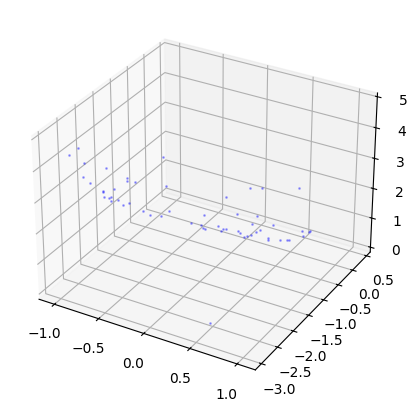

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from pycolmap import Reconstruction
import plotly.graph_objs as go

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=1, c='b', alpha=0.3, depthshade=False)

In [35]:
for x in reconstruction.images.values():
    print(x)

Image(image_id=1, camera=Camera(camera_id=6), name="r_13.png", has_pose=1, triangulated=225/3076)
Image(image_id=65, camera=Camera(camera_id=64), name="r_66.png", has_pose=1, triangulated=464/3817)
Image(image_id=49, camera=Camera(camera_id=51), name="r_54.png", has_pose=1, triangulated=834/3955)
Image(image_id=12, camera=Camera(camera_id=9), name="r_16.png", has_pose=1, triangulated=424/4358)
Image(image_id=5, camera=Camera(camera_id=11), name="r_18.png", has_pose=1, triangulated=490/3564)
Image(image_id=69, camera=Camera(camera_id=69), name="r_9.png", has_pose=1, triangulated=787/3920)
Image(image_id=27, camera=Camera(camera_id=26), name="r_31.png", has_pose=1, triangulated=669/3814)
Image(image_id=43, camera=Camera(camera_id=41), name="r_45.png", has_pose=1, triangulated=728/3939)
Image(image_id=55, camera=Camera(camera_id=55), name="r_58.png", has_pose=1, triangulated=570/4096)
Image(image_id=8, camera=Camera(camera_id=7), name="r_14.png", has_pose=1, triangulated=629/3928)
Image(i

In [63]:
camera_translations_array = np.stack(camera_translations)

fig = go.Figure(data=[go.Scatter3d(
    x=camera_translations_array[:, 0],
    y=camera_translations_array[:, 1],
    z=camera_translations_array[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=camera_translations_array[:, 2],  # Color by Z value for effect
        colorscale='Viridis',
        opacity=0.7
    )
)])

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    title='Interactive 3D Points from COLMAP Reconstruction',
    width=500,
    height=500
)
fig.show()